# Serve Recommendation System

This notebook converts the trained predictive model into a serve recommendation system that ranks possible serve choices under a specified match context. The system is designed as a **decision support tool** rather than an automated prescriptive system: it presents a ranked list of serve options with supporting evidence, but the final decision remains with the coach or player. A recommendation system that bypasses human judgment entirely is inappropriate in a sports context where factors such as fatigue, emotional state, and opponent-specific adjustments not captured in the historical data may be critical.

The recommendation score for each serve option is a weighted combination of the model's predicted win probability, the historical win rate for that specific serve combination, and a reliability score that reflects how many times that combination has been observed. This multi-component formula prevents the system from confidently recommending a serve that performed well only once or twice by chance, while still allowing novel combinations to be considered when the model assigns them a high predicted win probability.

## Load Model and Data

We load the trained model selected in the previous notebook, the saved feature list, and the processed dataset containing both raw serve attributes and engineered features. The feature list is essential for ensuring the inference pipeline uses exactly the same features in exactly the same order as the training pipeline. Any discrepancy in column ordering would cause the preprocessor to apply transformations to the wrong columns, producing silently incorrect predictions.

In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

df             = pd.read_csv('../data/processed/table_tennis_serves_features.csv')
model          = joblib.load('../models/serve_win_probability_model.pkl')
model_features = joblib.load('../models/model_features.pkl')

print(f'Loaded {len(df)} historical points and {len(model_features)} model features.')
print(f'Selected model: {model.named_steps["classifier"].__class__.__name__}')

Loaded 500 historical points and 33 model features.
Selected model: LogisticRegression


## Valid Context Domains

Before defining any match context, we extract the valid category values directly from the training data. This step exists because `OneHotEncoder(handle_unknown='ignore')` — used in the modeling pipeline — silently maps any unrecognized category to an all-zero vector instead of raising an error. A typo such as `"opponent_style": "attacker"` when the trained categories are `{looper, blocker, defender, allround}` would not crash the notebook; it would quietly produce a prediction that ignores opponent style entirely, with no warning. By extracting and validating against these domains explicitly, we convert a silent prediction error into a loud, immediate one.

In [22]:
context_categorical_fields = [
    'game_state', 'opponent_skill_level', 'opponent_style', 'side'
]

valid_domains = {
    field: sorted(df[field].unique().tolist())
    for field in context_categorical_fields
}

print('Valid values for each context field (derived from training data):')
for field, values in valid_domains.items():
    print(f'  {field:24s}: {values}')

Valid values for each context field (derived from training data):
  game_state              : ['deuce', 'game_point', 'leading', 'neutral', 'trailing']
  opponent_skill_level    : ['advanced', 'beginner', 'competitive', 'intermediate']
  opponent_style          : ['allround', 'blocker', 'defender', 'looper']
  side                    : ['backhand_side', 'forehand_side']


## Reusable Recommendation Pipeline

The original feature-reconstruction logic was duplicated across three separate cells: once for the main context, once inside the multi-context evaluation loop, and once for the closing guardrail check. Three independent copies of the same transformation logic is a maintenance hazard — if notebook 2's feature engineering changes, every copy here must be updated in lockstep, and a missed copy would silently produce stale features.

We instead define this logic **once**, as three small functions, and reuse them everywhere a context needs to be scored. This also makes the pipeline directly testable and reusable from outside the notebook (e.g. in a future Streamlit dashboard).

1. `validate_context` — raises immediately on an invalid categorical value, replacing the silent `handle_unknown='ignore'` failure mode with a loud one.
2. `build_candidate_features` — reconstructs the 33 engineered features for a set of serve options under a fixed context, mirroring notebook 2's logic exactly.
3. `score_context` — runs `build_candidate_features`, merges historical combo statistics, scores with the model, and computes the recommendation score in one call.

In [23]:
def validate_context(context, valid_domains):
    """Raise a clear error if any categorical context field is outside the values
    seen during training. Prevents the silent OneHotEncoder(handle_unknown='ignore')
    failure mode where an unrecognized category is mapped to an all-zero vector."""
    errors = []
    for field, valid_values in valid_domains.items():
        if field in context and context[field] not in valid_values:
            errors.append(
                f"  '{field}' = {context[field]!r} is not a valid value. "
                f"Valid options: {valid_values}"
            )
    if errors:
        raise ValueError("Invalid match context:\n" + "\n".join(errors))
    return True


def build_candidate_features(serve_options, context):
    """Reconstruct the engineered features for a candidate pool of serve options
    under a fixed match context. Mirrors the transformation logic in
    02_feature_engineering.ipynb exactly -- any change there must be reflected here."""
    rec = serve_options.copy()
    for key, value in context.items():
        rec[key] = value

    rec['score_margin']                  = rec['server_score'] - rec['receiver_score']
    rec['total_points_played_in_game']   = rec['server_score'] + rec['receiver_score']
    rec['is_tied']                       = (rec['server_score'] == rec['receiver_score']).astype(int)
    rec['is_trailing']                   = (rec['server_score'] <  rec['receiver_score']).astype(int)
    rec['is_leading']                    = (rec['server_score'] >  rec['receiver_score']).astype(int)
    rec['is_late_game']                  = (rec['total_points_played_in_game'] >= 16).astype(int)
    rec['is_deuce_or_later']             = ((rec['server_score'] >= 10) & (rec['receiver_score'] >= 10)).astype(int)
    rec['is_game_point_for_server']      = ((rec['server_score'] >= 10) & (rec['server_score'] > rec['receiver_score'])).astype(int)
    rec['is_game_point_against_server']  = ((rec['receiver_score'] >= 10) & (rec['receiver_score'] > rec['server_score'])).astype(int)

    rec['serve_spin_combo']        = rec['serve_type'] + '_' + rec['spin_type']
    rec['serve_length_spin_combo'] = rec['serve_length'] + '_' + rec['spin_type']
    rec['serve_placement_combo']   = rec['serve_type'] + '_' + rec['placement_zone']
    rec['full_serve_combo'] = (
        rec['serve_type'] + '_' + rec['spin_type'] + '_' +
        rec['serve_length'] + '_' + rec['placement_zone']
    )

    rec['is_heavy_spin'] = (rec['spin_intensity'] >= 3).astype(int)
    rec['is_low_spin']   = (rec['spin_intensity'] <= 1).astype(int)

    return rec


def score_context(serve_options, context, combo_summary, overall_win_rate,
                   model, model_features, valid_domains=None):
    """Full scoring pipeline for one match context: validate -> reconstruct features
    -> merge historical combo stats -> predict -> compute recommendation score."""
    if valid_domains is not None:
        validate_context(context, valid_domains)

    rec = build_candidate_features(serve_options, context)

    rec = rec.merge(combo_summary, on='full_serve_combo', how='left')
    rec['combo_attempts']    = rec['combo_attempts'].fillna(0)
    rec['combo_win_rate']    = rec['combo_win_rate'].fillna(overall_win_rate)
    rec['combo_reliability'] = np.minimum(rec['combo_attempts'] / 30, 1)

    rec['predicted_win_probability'] = model.predict_proba(rec[model_features])[:, 1]

    rec['recommendation_score'] = (
        0.70 * rec['predicted_win_probability'] +
        0.20 * rec['combo_win_rate'] +
        0.10 * rec['combo_reliability']
    )
    return rec


print('Defined: validate_context, build_candidate_features, score_context')

Defined: validate_context, build_candidate_features, score_context


## Candidate Serve Pool and Historical Combo Statistics

The candidate pool is built from all distinct combinations of serve attributes observed in the historical dataset, rather than the full Cartesian product of attribute values. The Cartesian product would include serve combinations that are physically impossible or have never appeared in competitive play, and the model's predictions for such combinations would be extrapolations with no empirical grounding. Restricting candidates to historically observed combinations ensures every prediction is at least partially anchored in real data.

We also compute `combo_summary` and `overall_win_rate` once here, since both the single-context flow and the multi-context comparison below need the same historical statistics.

In [24]:
serve_attribute_cols = [
    'serve_type', 'spin_type', 'spin_intensity', 'serve_length',
    'placement_zone', 'toss_height', 'contact_point', 'intended_setup'
]
serve_options = df[serve_attribute_cols].drop_duplicates().reset_index(drop=True)

combo_summary = (
    df.groupby('full_serve_combo')
      .agg(combo_attempts=('point_won', 'count'), combo_win_rate=('point_won', 'mean'))
      .reset_index()
)
overall_win_rate = df['point_won'].mean()

print(f'Candidate pool          : {len(serve_options)} unique serve attribute combinations')
print(f'Historical combo records: {len(combo_summary)} distinct full_serve_combo values')
print(f'Overall win rate         : {overall_win_rate:.1%}  (imputed for unseen combinations)')
serve_options.head()

Candidate pool          : 466 unique serve attribute combinations
Historical combo records: 151 distinct full_serve_combo values
Overall win rate         : 45.6%  (imputed for unseen combinations)


,serve_type,spin_type,spin_intensity,serve_length,placement_zone,toss_height,contact_point,intended_setup
0,backhand,float/no-spin,1,long,middle_FH,medium,body_center,force_weak_push
1,backhand,float/no-spin,1,long,elbow,medium,body_center,force_pop_up
2,backhand,float/no-spin,2,long,elbow,low,hip_level_backhand,start_chop_rally
3,backhand,float/no-spin,1,long,elbow,medium,hip_level_backhand,force_weak_push
4,backhand,float/no-spin,1,short,elbow,low,body_center,force_weak_push


## Define Match Context

The match context specifies the conditions under which the serve is about to be executed. `game_number` matters because players often adjust strategy across games as they learn more about their opponent. `server_score` and `receiver_score` determine all of the game-state flags constructed in feature engineering. `game_state` is a categorical label the model uses directly. `opponent_skill_level` and `opponent_style` determine which serves are expected to be most effective given the opponent's technical profile. `side` constrains the physically comfortable serve options.

We validate the context immediately against `valid_domains` before doing anything else, so a typo surfaces as an error here rather than as a silently degraded prediction further down the notebook.

In [25]:
current_context = {
    'game_number': 2,
    'server_score': 8,
    'receiver_score': 7,
    'game_state': 'neutral',
    'opponent_skill_level': 'advanced',
    'opponent_style': 'looper',
    'side': 'backhand_side'
}

validate_context(current_context, valid_domains)
print('Context is valid.')
current_context

Context is valid.


{'game_number': 2,
 'server_score': 8,
 'receiver_score': 7,
 'game_state': 'neutral',
 'opponent_skill_level': 'advanced',
 'opponent_style': 'looper',
 'side': 'backhand_side'}

## Score All Candidate Serves Under This Context

We call `score_context` once to run the full pipeline: feature reconstruction, historical combo lookup, model prediction, and recommendation scoring. The model-predicted win probability receives a weight of 0.70 because it is the most general and context-sensitive signal, having been trained on the full feature set including game state, opponent characteristics, and serve attributes jointly. The historical win rate for the specific combination receives 0.20 because it captures serve-level performance patterns the model may not fully represent. The reliability score receives 0.10 because it functions as a correction factor: a combination with a high win rate but only two observations should not be promoted above a well-tested combination with a slightly lower rate.

In [26]:
recommendation_df = score_context(
    serve_options, current_context, combo_summary, overall_win_rate,
    model, model_features, valid_domains
)

print(f'Scored {len(recommendation_df)} candidate serve options.')
print(f'Predicted win probability range: '
      f'{recommendation_df["predicted_win_probability"].min():.3f} - '
      f'{recommendation_df["predicted_win_probability"].max():.3f}')
recommendation_df[['serve_type','spin_type','placement_zone',
                    'predicted_win_probability','combo_win_rate',
                    'combo_attempts','recommendation_score']].head()

Scored 466 candidate serve options.
Predicted win probability range: 0.218 - 0.819


,serve_type,spin_type,placement_zone,predicted_win_probability,combo_win_rate,combo_attempts,recommendation_score
0,backhand,float/no-spin,middle_FH,0.244331,0.000000,2,0.177698
1,backhand,float/no-spin,elbow,0.252236,0.000000,4,0.189899
2,backhand,float/no-spin,elbow,0.277155,0.000000,4,0.207342
3,backhand,float/no-spin,elbow,0.239088,0.000000,4,0.180695
4,backhand,float/no-spin,elbow,0.331612,0.166667,6,0.285462


## Top Recommendations

The top 10 serve options ranked by recommendation score, with all component scores visible. Showing component scores alongside the aggregate is important for transparency: a coach should be able to verify whether a high score is driven by the model, by historical performance, or by both, and should be appropriately cautious about options whose high score is driven entirely by one component while the other is low or based on minimal data.

In [27]:
display_cols = [
    'serve_type', 'spin_type', 'spin_intensity', 'serve_length', 'placement_zone',
    'intended_setup', 'predicted_win_probability', 'combo_win_rate',
    'combo_attempts', 'combo_reliability', 'recommendation_score'
]

top_recommendations = (
    recommendation_df.sort_values('recommendation_score', ascending=False)
    [display_cols]
    .head(10)
    .reset_index(drop=True)
)
top_recommendations

,serve_type,spin_type,spin_intensity,serve_length,placement_zone,intended_setup,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score
0,backhand,backspin,3,half_long,elbow,force_pop_up,0.818998,1.0,4,0.133333,0.786632
1,backhand,backspin,3,half_long,elbow,start_chop_rally,0.817607,1.0,4,0.133333,0.785659
2,backhand,backspin,3,long,elbow,start_chop_rally,0.810917,1.0,2,0.066667,0.774309
3,reverse_pendulum,sidespin-top,3,short,wide_BH,force_pop_up,0.814471,1.0,1,0.033333,0.773463
4,backhand,sidespin-back,3,half_long,wide_BH,start_chop_rally,0.814170,1.0,1,0.033333,0.773252
5,backhand,sidespin-back,3,half_long,wide_FH,start_chop_rally,0.807690,1.0,1,0.033333,0.768716
6,backhand,sidespin-back,3,long,middle_BH,force_weak_push,0.805789,1.0,1,0.033333,0.767386
7,pendulum,sidespin-back,3,long,middle_FH,force_weak_push,0.798811,1.0,2,0.066667,0.765835
8,pendulum,sidespin-back,3,half_long,wide_FH,start_chop_rally,0.802421,1.0,1,0.033333,0.765028
9,backhand,sidespin-back,3,long,middle_FH,force_weak_push,0.801668,1.0,1,0.033333,0.764501


## Explanation Generation

Each recommendation is accompanied by a natural-language explanation. A "high predicted win probability" reason indicates a model-estimated win probability of 60% or above. A "reliable historical sample" reason indicates the combination has been attempted at least 15 times (`combo_reliability >= 0.5`). A "strong historical win rate" reason indicates an observed win rate of at least 60%. An "uses heavy spin" reason highlights a known difficult-to-return attribute. When a combination has zero historical attempts, the explanation flags it explicitly so the coach knows the recommendation is based entirely on the model's generalization from similar combinations, with no direct empirical support.

In [28]:
def explain_recommendation(row):
    reasons = []
    if row['predicted_win_probability'] >= 0.60:
        reasons.append('high predicted win probability')
    elif row['predicted_win_probability'] >= 0.55:
        reasons.append('moderate predicted win probability')
    if row['combo_reliability'] >= 0.70:
        reasons.append('reliable historical sample')
    if row['combo_win_rate'] >= 0.60:
        reasons.append('strong historical win rate')
    if row['spin_intensity'] >= 3:
        reasons.append('uses heavy spin')
    if row['combo_attempts'] == 0:
        reasons.append('untested combination -- use with caution')
    return ', '.join(reasons) if reasons else 'no standout factors'

top_recommendations = top_recommendations.copy()
top_recommendations['reason'] = top_recommendations.apply(explain_recommendation, axis=1)
top_recommendations

,serve_type,spin_type,spin_intensity,serve_length,placement_zone,intended_setup,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score,reason
0,backhand,backspin,3,half_long,elbow,force_pop_up,0.818998,1.0,4,0.133333,0.786632,"high predicted win probability, strong histori..."
1,backhand,backspin,3,half_long,elbow,start_chop_rally,0.817607,1.0,4,0.133333,0.785659,"high predicted win probability, strong histori..."
2,backhand,backspin,3,long,elbow,start_chop_rally,0.810917,1.0,2,0.066667,0.774309,"high predicted win probability, strong histori..."
3,reverse_pendulum,sidespin-top,3,short,wide_BH,force_pop_up,0.814471,1.0,1,0.033333,0.773463,"high predicted win probability, strong histori..."
4,backhand,sidespin-back,3,half_long,wide_BH,start_chop_rally,0.814170,1.0,1,0.033333,0.773252,"high predicted win probability, strong histori..."
5,backhand,sidespin-back,3,half_long,wide_FH,start_chop_rally,0.807690,1.0,1,0.033333,0.768716,"high predicted win probability, strong histori..."
6,backhand,sidespin-back,3,long,middle_BH,force_weak_push,0.805789,1.0,1,0.033333,0.767386,"high predicted win probability, strong histori..."
7,pendulum,sidespin-back,3,long,middle_FH,force_weak_push,0.798811,1.0,2,0.066667,0.765835,"high predicted win probability, strong histori..."
8,pendulum,sidespin-back,3,half_long,wide_FH,start_chop_rally,0.802421,1.0,1,0.033333,0.765028,"high predicted win probability, strong histori..."
9,backhand,sidespin-back,3,long,middle_FH,force_weak_push,0.801668,1.0,1,0.033333,0.764501,"high predicted win probability, strong histori..."


## Serve Type Frequency in Top Recommendations

A serve type that appears frequently among the top 10 recommendations is consistently favored by the scoring formula under the current context. This is a quick sanity check: if all 10 recommendations share the same serve type, the candidate pool or feature set may not contain enough variation to distinguish among types. A diverse set, by contrast, suggests context-sensitive discrimination.

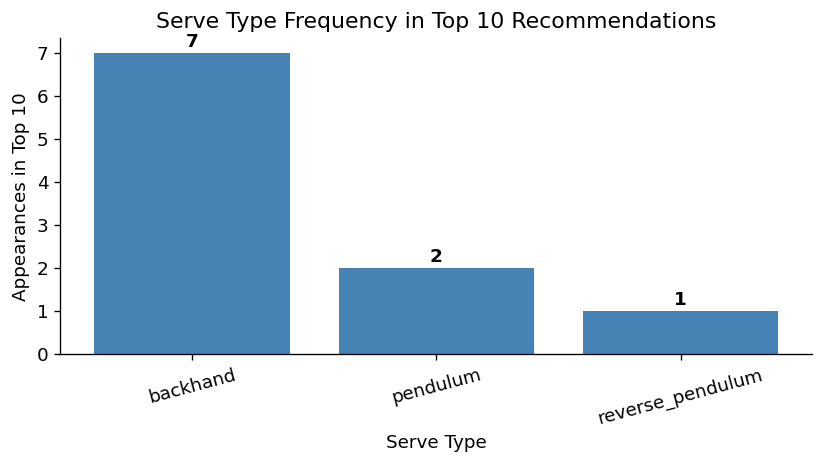

In [29]:
serve_type_counts = top_recommendations['serve_type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(serve_type_counts.index, serve_type_counts.values, color='steelblue')
ax.set_xlabel('Serve Type')
ax.set_ylabel('Appearances in Top 10')
ax.set_title('Serve Type Frequency in Top 10 Recommendations')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(ax.patches, serve_type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/top10_serve_type_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## Score Distribution

The distribution of recommendation scores across all candidate serve options reveals how discriminating the scoring formula is. A tightly clustered distribution would indicate the formula is not effectively differentiating among options. A wide spread, with clear separation between the top options and the bulk, indicates the formula identifies a genuinely distinct set of favored serves.

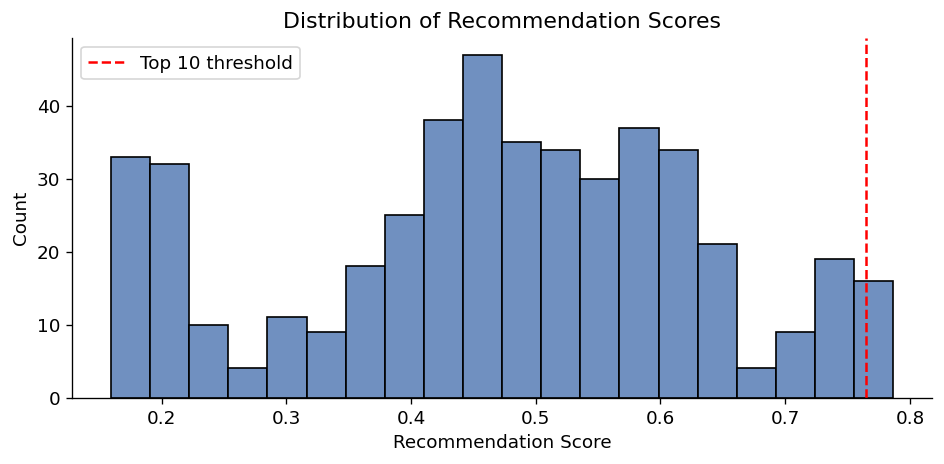

Top-10 cutoff score : 0.7645
Full pool mean      : 0.4699
Full pool std       : 0.1636


In [30]:
threshold_score = (
    recommendation_df.sort_values('recommendation_score', ascending=False)
    ['recommendation_score'].iloc[9]
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recommendation_df['recommendation_score'], bins=20, edgecolor='black', color='#7090c0')
ax.axvline(threshold_score, color='red', linestyle='--', label='Top 10 threshold')
ax.set_title('Distribution of Recommendation Scores')
ax.set_xlabel('Recommendation Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/recommendation_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top-10 cutoff score : {threshold_score:.4f}')
print(f'Full pool mean      : {recommendation_df["recommendation_score"].mean():.4f}')
print(f'Full pool std       : {recommendation_df["recommendation_score"].std():.4f}')

## High Confidence Filter

Restricts the recommendation pool to combinations observed at least 15 times (`combo_reliability >= 0.5`). Appropriate when the practitioner wants recommendations grounded in a meaningful amount of historical evidence, accepting a smaller candidate pool in exchange for reduced uncertainty. A combination observed once or twice can show extreme win rates by chance; this filter guarantees every recommendation in the restricted pool is based on at least 15 trials. The tradeoff is that novel combinations are excluded even if the model predicts them to be highly effective.

_Note: `src/run_pipeline.py`'s `recommend` CLI now applies this same `combo_reliability >= 0.5` filter by default (pass `--min-reliability 0.0` to see the unfiltered ranking), so CLI output matches this notebook's high-confidence view unless overridden._

In [31]:
reliable_pool = recommendation_df[recommendation_df['combo_reliability'] >= 0.5]

reliable_recommendations = (
    reliable_pool
    .sort_values('recommendation_score', ascending=False)
    [['serve_type', 'spin_type', 'spin_intensity', 'serve_length', 'placement_zone',
      'predicted_win_probability', 'combo_win_rate', 'combo_attempts',
      'combo_reliability', 'recommendation_score']]
    .head(10)
    .reset_index(drop=True)
)

print(f'Filtered from {len(recommendation_df)} to {len(reliable_pool)} serve options '
      f'with combo_reliability >= 0.5')
reliable_recommendations

Filtered from 466 to 38 serve options with combo_reliability >= 0.5


,serve_type,spin_type,spin_intensity,serve_length,placement_zone,predicted_win_probability,combo_win_rate,combo_attempts,combo_reliability,recommendation_score
0,short_backspin,backspin,3,short,elbow,0.638810,0.578947,19,0.633333,0.626290
1,short_backspin,backspin,3,short,elbow,0.638601,0.578947,19,0.633333,0.626144
2,short_backspin,backspin,3,short,elbow,0.637238,0.578947,19,0.633333,0.625190
3,short_backspin,backspin,3,short,elbow,0.630148,0.578947,19,0.633333,0.620226
4,short_backspin,backspin,3,short,elbow,0.625988,0.578947,19,0.633333,0.617315
5,short_backspin,backspin,3,short,elbow,0.625558,0.578947,19,0.633333,0.617013
6,short_backspin,backspin,3,short,elbow,0.616982,0.578947,19,0.633333,0.611010
7,short_backspin,backspin,3,short,elbow,0.615507,0.578947,19,0.633333,0.609978
8,short_backspin,backspin,3,short,elbow,0.615071,0.578947,19,0.633333,0.609673
9,short_backspin,backspin,2,short,elbow,0.594319,0.578947,19,0.633333,0.595146


## Multi-Context Evaluation

A key test of the recommendation system's utility is whether it produces meaningfully different recommendations under different match contexts. If the same serve always ranks first regardless of context, the contextual variables are not influencing recommendations — suggesting either the model has not learned context-sensitive patterns or the feature engineering does not capture the relevant distinctions.

We evaluate three contrasting contexts, all validated against `valid_domains` before scoring: a neutral early-game point against a looping opponent at a tied score; a high-pressure deuce point in game 3 against an all-round opponent; and a trailing position against a defensive opponent in game 2. These differ in score pressure, opponent style, and match situation, and should produce distinguishably different serve recommendations if the model is functioning as intended.

Each context is scored using the same `score_context` function used above — there is no separate copy of the feature-reconstruction logic here.

In [32]:
contexts = [
    {
        'label': 'Neutral point vs looper',
        'game_number': 1, 'server_score': 4, 'receiver_score': 4,
        'game_state': 'neutral', 'opponent_skill_level': 'advanced',
        'opponent_style': 'looper', 'side': 'backhand_side'
    },
    {
        'label': 'High-pressure deuce vs all-round opponent',
        'game_number': 3, 'server_score': 10, 'receiver_score': 10,
        'game_state': 'deuce', 'opponent_skill_level': 'advanced',
        'opponent_style': 'allround', 'side': 'forehand_side'
    },
    {
        'label': 'Trailing vs defender',
        'game_number': 2, 'server_score': 6, 'receiver_score': 9,
        'game_state': 'trailing', 'opponent_skill_level': 'advanced',
        'opponent_style': 'defender', 'side': 'backhand_side'
    }
]

context_results = {}

for ctx in contexts:
    label = ctx['label']
    ctx_fields = {k: v for k, v in ctx.items() if k != 'label'}

    rec = score_context(
        serve_options, ctx_fields, combo_summary, overall_win_rate,
        model, model_features, valid_domains
    )
    context_results[label] = rec

    print(f'\n=== Context: {label} ===')
    top5 = (
        rec.sort_values('recommendation_score', ascending=False)
        [['serve_type', 'spin_type', 'spin_intensity', 'serve_length',
          'placement_zone', 'recommendation_score']]
        .head(5)
    )
    print(top5.to_string(index=False))


=== Context: Neutral point vs looper ===
      serve_type     spin_type  spin_intensity serve_length placement_zone  recommendation_score
        backhand      backspin               3    half_long          elbow              0.773844
        backhand      backspin               3    half_long          elbow              0.772797
        backhand      backspin               3         long          elbow              0.761096
reverse_pendulum  sidespin-top               3        short        wide_BH              0.760436
        backhand sidespin-back               3    half_long        wide_BH              0.760209

=== Context: High-pressure deuce vs all-round opponent ===
      serve_type     spin_type  spin_intensity serve_length placement_zone  recommendation_score
        backhand      backspin               3    half_long          elbow              0.787341
        backhand      backspin               3    half_long          elbow              0.786372
        backhand      bac

## Pivot Table and Heatmap: Serve Types Across Contexts

The pivot table and heatmap aggregate mean recommendation scores by serve type and context, enabling systematic comparison of which serve types are consistently effective across situations versus strongly context-specific. A serve type with uniformly high scores across all contexts is a generalist option; a serve type with high scores in one context and low in another is a specialist that should be deployed selectively. This cross-context view is one of the most actionable outputs of the system, supporting a serve selection strategy that is context-sensitive and evidence-based rather than intuition-driven.

In [33]:
pivot_rows = []
for label, rec in context_results.items():
    mean_scores = rec.groupby('serve_type')['recommendation_score'].mean()
    pivot_rows.append(mean_scores.rename(label))

pivot_df = pd.DataFrame(pivot_rows).T
pivot_df.index.name = 'serve_type'
pivot_df.columns.name = 'context'
pivot_df

context,Neutral point vs looper,High-pressure deuce vs all-round opponent,Trailing vs defender
serve_type,,,
backhand,0.440263,0.458763,0.404874
no_spin_disguised,0.453625,0.473355,0.415886
pendulum,0.459999,0.480567,0.420527
reverse_pendulum,0.417345,0.436622,0.380659
short_backspin,0.491913,0.512752,0.451626
tomahawk,0.411022,0.431155,0.372837


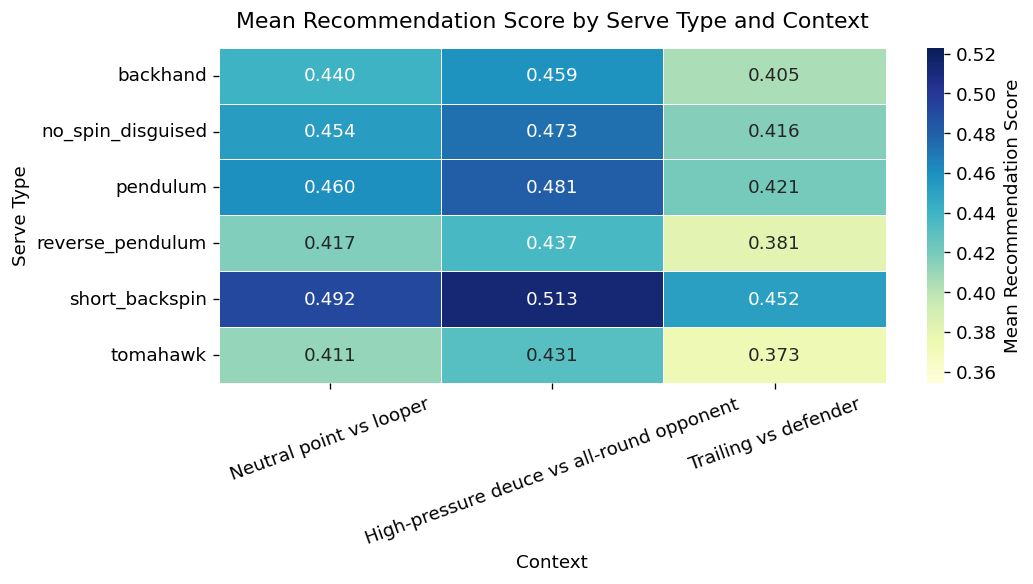

Serve types ranked by context-sensitivity (max score - min score across contexts):
serve_type
short_backspin       0.061126
pendulum             0.060041
tomahawk             0.058319
no_spin_disguised    0.057469
reverse_pendulum     0.055963
backhand             0.053890


In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_df,
    annot=True, fmt='.3f', cmap='YlGnBu',
    vmin=pivot_df.min().min() * 0.95, vmax=pivot_df.max().max() * 1.02,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean Recommendation Score'}
)
ax.set_title('Mean Recommendation Score by Serve Type and Context', pad=12)
ax.set_xlabel('Context')
ax.set_ylabel('Serve Type')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/serve_type_by_context_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

row_range = (pivot_df.max(axis=1) - pivot_df.min(axis=1)).sort_values(ascending=False)
print('Serve types ranked by context-sensitivity (max score - min score across contexts):')
print(row_range.to_string())

## Score Margin Sensitivity Analysis

*(New addition.)* While the multi-context comparison above varies several context fields simultaneously, it cannot isolate the marginal effect of any single factor. Here we hold every context field fixed except `server_score`, sweeping it from 0 to 16 against a fixed `receiver_score`, and track how the **best available recommendation score** changes as the game state moves from trailing through tied to leading. This answers a sharper question for coaches: *as the score shifts, does the system's best serve option get systematically stronger or weaker, and is that shift smooth or does it jump at specific thresholds* (e.g. crossing into deuce territory)?

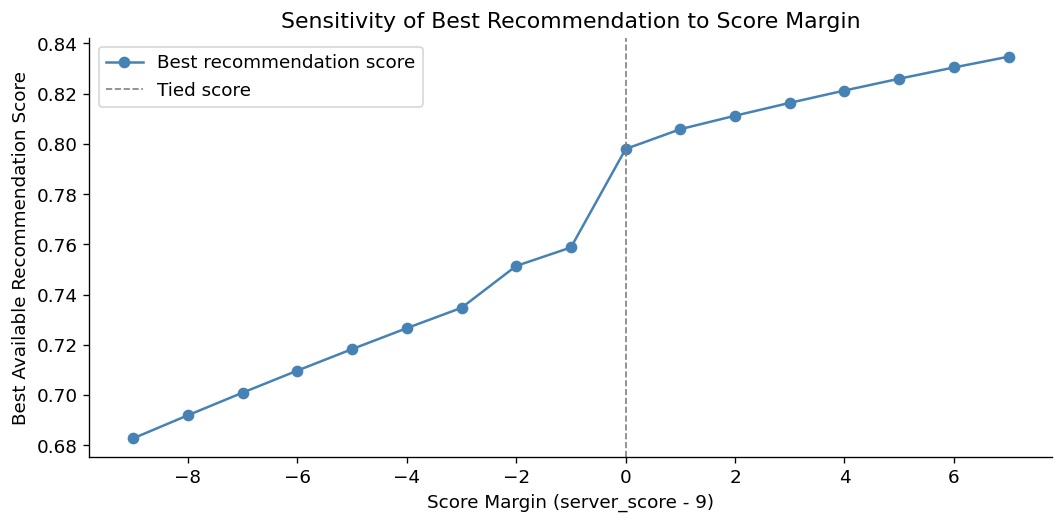

,server_score,score_margin,game_state,best_recommendation_score,best_predicted_win_probability
0,0,-9,trailing,0.682739,0.670580
1,1,-8,trailing,0.691932,0.683712
2,2,-7,trailing,0.700924,0.696558
3,3,-6,trailing,0.709706,0.709104
4,4,-5,trailing,0.718270,0.721338
5,5,-4,trailing,0.726610,0.733252
6,6,-3,trailing,0.734719,0.744836
7,7,-2,trailing,0.751400,0.768667
8,8,-1,trailing,0.758757,0.779177
9,9,0,neutral,0.797976,0.835204


In [35]:
fixed_receiver_score = 9
sweep_scores = list(range(0, 17))

sensitivity_rows = []
for server_score in sweep_scores:
    if server_score == fixed_receiver_score:
        game_state = 'deuce' if server_score >= 10 else 'neutral'
    elif server_score > fixed_receiver_score:
        game_state = 'game_point' if server_score >= 10 else 'leading'
    else:
        game_state = 'trailing'

    sweep_ctx = {
        'game_number': 2,
        'server_score': server_score,
        'receiver_score': fixed_receiver_score,
        'game_state': game_state,
        'opponent_skill_level': 'advanced',
        'opponent_style': 'looper',
        'side': 'backhand_side'
    }
    rec = score_context(
        serve_options, sweep_ctx, combo_summary, overall_win_rate,
        model, model_features, valid_domains
    )
    sensitivity_rows.append({
        'server_score': server_score,
        'score_margin': server_score - fixed_receiver_score,
        'game_state': game_state,
        'best_recommendation_score': rec['recommendation_score'].max(),
        'best_predicted_win_probability': rec.loc[rec['recommendation_score'].idxmax(), 'predicted_win_probability']
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sensitivity_df['score_margin'], sensitivity_df['best_recommendation_score'],
        marker='o', color='steelblue', label='Best recommendation score')
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='Tied score')
ax.set_xlabel(f'Score Margin (server_score - {fixed_receiver_score})')
ax.set_ylabel('Best Available Recommendation Score')
ax.set_title('Sensitivity of Best Recommendation to Score Margin')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/score_margin_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

sensitivity_df

## Summary and Limitations

This notebook converts a trained predictive model into a structured serve recommendation system. The scoring formula integrates three complementary sources of evidence: model-predicted win probability (70%), historical win rate for the specific combination (20%), and a sample-size reliability correction (10%). Recommendations differ meaningfully across match contexts and along a single-variable score margin sweep, which is a positive indicator that the model has learned context-sensitive patterns from the feature set.

Several limitations of the current system should be noted.

- **Historical and training data overlap.** The historical data used to compute `combo_win_rate` and `combo_reliability` comes from the same matches used to train the model, so combinations attempted frequently in training data receive more reliable historical scores than those attempted rarely, and this data collection pattern is not itself random.
- **No serve sequencing.** The system does not account for serve variation and the importance of unpredictability over a sequence of points. Optimizing each serve independently in isolation may produce patterns an experienced opponent can anticipate and exploit.
- **Missing real-world context.** Factors such as the server's physical condition, specific match history between the two players, and the psychological dynamics of the moment cannot be incorporated.
- **Candidate pool is historically bounded.** Serve combinations with zero historical attempts are scored using only the model's generalization and the imputed overall win rate; they receive zero weight from the historical component by construction.

The serve recommendation system should therefore be treated as a structured starting point for tactical preparation and review, not as a prescriptive algorithm to be followed mechanically during live play. As more match data is collected, the reliability of historical estimates will improve, imputed win rates for novel combinations will be replaced with real observations, and the model can be periodically retrained to incorporate updated patterns.

## Feature Alignment Guardrail

As a final safety check, we verify the recommendation dataframe contains exactly the features the model expects, in the correct order. This guardrail catches any mismatch between the column set used at inference time and the column set used during training — a mismatch that would otherwise cause the preprocessing pipeline to silently apply transformations to the wrong columns. The alignment function adds any missing columns using a fallback value and then reorders columns to match the training feature list exactly. An assertion confirms alignment succeeded before inference is performed.

This check is run against `recommendation_df` from the single-context flow above, reusing the same object rather than recomputing it.

In [36]:
def align_features_for_model(input_df, model_features, fallback_row):
    aligned = input_df.copy()
    for col in model_features:
        if col not in aligned.columns:
            aligned[col] = fallback_row.get(col, 0)
    return aligned[model_features]

fallback_values = df.mode(numeric_only=False).iloc[0].to_dict()
aligned_features = align_features_for_model(recommendation_df, model_features, fallback_values)

assert list(aligned_features.columns) == list(model_features), \
    'Column mismatch between recommendation_df and model_features'
assert aligned_features.isnull().sum().sum() == 0, \
    'Aligned features contain unexpected nulls'

print('Feature alignment check passed for recommendation inference.')
print(f'  Columns aligned : {len(aligned_features.columns)} / {len(model_features)}')
print(f'  Null values     : {aligned_features.isnull().sum().sum()}')

Feature alignment check passed for recommendation inference.
  Columns aligned : 33 / 33
  Null values     : 0
